# Glove Data Visualiser

Visualise raw and filtered glove sensor data for individual segments and apply filtering techniques interactively.

**Layout:**
- **Section 0** — Install / import dependencies
- **Section 1** — Configuration (data path, hand, file selection, sampling rate)
- **Section 2** — Load a single CSV trial
- **Section 3** — Filter configuration (choose technique and parameters)
- **Section 4** — Segment plots (Thumb mid + Thumb prox)
- **Section 5** — Overlay: raw vs filtered comparison
- **Section 6** — FFT spectrum (pre- and post-filter)

---
**Column naming convention in the dataset:**
```
{hand}_{segment}_{loc}_{channel}

Examples:
  left_thumb_mid_ax        right_thumb_prox_pitch
  left_thumb_mcp_flex  right_thumb_pip_flex
```
Set `HAND` in Section 1 to switch between `'left'` and `'right'`.

---
## 0. Dependencies

In [33]:
import subprocess, sys
pkgs = ['pandas', 'numpy', 'matplotlib', 'scipy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('Dependencies ready.')

Dependencies ready.


In [34]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal
from scipy.fft import rfft, rfftfreq

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK.')

Imports OK.


---
## 1. Configuration

Edit this cell to control which file and hand is visualised.

In [45]:
# =============================================================================
# 1A.  DATA PATH
# =============================================================================
# Path to a gesture FOLDER (one of the label subdirectories) OR a single CSV.
# If a folder is given, the first CSV inside is loaded by default.
# Accepts absolute paths or paths relative to this notebook.
#
# Example (folder):  '../data/TwoHand_L_Fist_R_Fist'
# Example (file):    '../data/TwoHand_L_Fist_R_Fist/trial_001.csv'

DATA_PATH = '/home/jestin/ThesisRepo/ML/3D_Reconstruction/glove_data_flat2fist_2s_1_2026-04-26_16-41-36.csv'          # <-- point this to your data folder or CSV


# If DATA_PATH is a folder, which file index to pick (0 = first file)
FILE_INDEX = 0

# =============================================================================
# 1B.  HAND
# =============================================================================
# Which hand's sensors to visualise.
# Options: 'left'  |  'right'
HAND = 'right'

# =============================================================================
# 1C.  SAMPLING RATE
# =============================================================================
# Approximate sample rate of the glove in Hz.
# Used for time-axis scaling and filter design.
FS_HZ = 22.0

# =============================================================================
# 1D.  TIME AXIS
# =============================================================================
# If True, use the column below as the time axis (ms → s conversion applied).
# If False, a synthetic time axis is generated from FS_HZ.
USE_TIMESTAMP_COLUMN = True
TIMESTAMP_COL        = None    # Set to column name, e.g. 'right_recv_time_ms'
                               # Leave None to auto-detect the first *_time_ms column

print('Configuration loaded.')
print(f'  Hand         : {HAND}')
print(f'  Sampling rate: {FS_HZ} Hz')
print(f'  Data path    : {DATA_PATH}')

Configuration loaded.
  Hand         : right
  Sampling rate: 22.0 Hz
  Data path    : /home/jestin/ThesisRepo/ML/3D_Reconstruction/glove_data_flat2fist_2s_1_2026-04-26_16-41-36.csv


---
## 2. Load Data

In [46]:
# ── Resolve file path ──────────────────────────────────────────────────────────
data_path = os.path.expanduser(DATA_PATH)

if os.path.isdir(data_path):
    csv_files = sorted(glob.glob(os.path.join(data_path, '**/*.csv'), recursive=True))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found under: {data_path}')
    csv_path = csv_files[FILE_INDEX]
    print(f'Found {len(csv_files)} CSV(s) in folder. Loading index {FILE_INDEX}:')
    print(f'  {os.path.basename(csv_path)}')
elif os.path.isfile(data_path):
    csv_path = data_path
    print(f'Loading file: {os.path.basename(csv_path)}')
else:
    raise FileNotFoundError(
        f"DATA_PATH not found: '{data_path}'\n"
        "Please update DATA_PATH in Section 1 to point to your data folder or CSV."
    )

# ── Read CSV ───────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)
print(f'\nLoaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

# ── Build time axis ────────────────────────────────────────────────────────────
if USE_TIMESTAMP_COLUMN:
    ts_col = TIMESTAMP_COL
    if ts_col is None:
        # Auto-detect: prefer HAND-specific time column, fall back to any *_time_ms
        candidates = [c for c in df_raw.columns if f'{HAND}' in c and 'time_ms' in c]
        if not candidates:
            candidates = [c for c in df_raw.columns if 'time_ms' in c]
        ts_col = candidates[0] if candidates else None

    if ts_col and ts_col in df_raw.columns:
        t = (df_raw[ts_col].values - df_raw[ts_col].values[0]) / 1000.0  # ms → s
        print(f'Time axis from column: {ts_col}  (duration: {t[-1]:.2f} s)')
    else:
        t = np.arange(len(df_raw)) / FS_HZ
        print(f'Synthetic time axis at {FS_HZ} Hz  (duration: {t[-1]:.2f} s)')
else:
    t = np.arange(len(df_raw)) / FS_HZ
    print(f'Synthetic time axis at {FS_HZ} Hz  (duration: {t[-1]:.2f} s)')

# ── Helper: safe column getter ─────────────────────────────────────────────────
def get_col(df, name):
    """Return column as numpy array, or NaN array if missing."""
    if name in df.columns:
        return df[name].to_numpy(dtype=float)
    print(f'  WARNING: column not found → {name}')
    return np.full(len(df), np.nan)

# ── Preview available glove columns ───────────────────────────────────────────
glove_cols = [c for c in df_raw.columns if c.startswith(f'{HAND}_thumb') or
                                           c.startswith(f'{HAND}_index') or
                                           c.startswith(f'{HAND}_middle')]
print(f'\nSample glove columns for "{HAND}" hand (first 20):')
for c in sorted(glove_cols)[:20]:
    print(f'  {c}')
print()
print('Raw data loaded. Proceed to Section 3 to configure filtering.')

Loading file: glove_data_flat2fist_2s_1_2026-04-26_16-41-36.csv

Loaded: 65 rows × 295 columns
Time axis from column: right_recv_time_ms  (duration: 3.53 s)

Sample glove columns for "right" hand (first 20):
  right_index_mcp_flex
  right_index_mid_ax
  right_index_mid_ay
  right_index_mid_az
  right_index_mid_pitch
  right_index_mid_quat_w
  right_index_mid_quat_x
  right_index_mid_quat_y
  right_index_mid_quat_z
  right_index_mid_roll
  right_index_mid_yaw
  right_index_pip_flex
  right_index_prox_ax
  right_index_prox_ay
  right_index_prox_az
  right_index_prox_pitch
  right_index_prox_quat_w
  right_index_prox_quat_x
  right_index_prox_quat_y
  right_index_prox_quat_z

Raw data loaded. Proceed to Section 3 to configure filtering.


---
## 3. Filter Configuration

Choose a filtering technique and tune its parameters here.  
Run **Section 4** and **Section 5** after changing anything to see the effect.

In [47]:
# =============================================================================
# SELECT FILTER
# =============================================================================
# Options:
#   'none'              — no filtering, pass raw signal through
#   'butterworth_lp'    — Butterworth low-pass (removes high-freq noise)
#   'butterworth_hp'    — Butterworth high-pass (removes DC / slow drift)
#   'butterworth_bp'    — Butterworth band-pass
#   'moving_average'    — Simple moving average (causal)
#   'savgol'            — Savitzky-Golay (smooths while preserving peaks)
#   'median'            — Median filter (good for spike / impulse noise)

FILTER_TYPE = 'butterworth_lp'

# =============================================================================
# BUTTERWORTH PARAMETERS  (used for butterworth_lp / hp / bp)
# =============================================================================
BW_ORDER     = 4          # Filter order (higher = sharper cutoff, more ringing)
BW_CUTOFF_LO = 5.0        # Low-pass or band-pass lower cutoff  (Hz)
BW_CUTOFF_HI = 10.0       # High-pass or band-pass upper cutoff (Hz)  [band-pass only]
BW_ZERO_PHASE = True      # True = zero-phase (filtfilt), False = causal (lfilter)

# =============================================================================
# MOVING AVERAGE PARAMETERS  (used for moving_average)
# =============================================================================
MA_WINDOW = 5             # Window length in samples

# =============================================================================
# SAVITZKY-GOLAY PARAMETERS  (used for savgol)
# =============================================================================
SG_WINDOW = 11            # Window length in samples (must be odd)
SG_POLYORDER = 3          # Polynomial order (must be < SG_WINDOW)

# =============================================================================
# MEDIAN FILTER PARAMETERS  (used for median)
# =============================================================================
MED_KERNEL = 5            # Kernel size in samples (must be odd)

# =============================================================================
# ── Apply filter function ──────────────────────────────────────────────────────
# =============================================================================

def apply_filter(signal, filter_type, fs):
    """Apply the configured filter to a 1-D signal array. Returns filtered array."""
    sig = np.array(signal, dtype=float)
    nan_mask = np.isnan(sig)
    if nan_mask.all():
        return sig   # nothing to filter

    ft = filter_type.lower()
    nyq = fs / 2.0

    if ft == 'none':
        return sig

    elif ft == 'butterworth_lp':
        cutoff = min(BW_CUTOFF_LO / nyq, 0.999)
        b, a = sp_signal.butter(BW_ORDER, cutoff, btype='low')
        filt_fn = sp_signal.filtfilt if BW_ZERO_PHASE else sp_signal.lfilter
        return filt_fn(b, a, sig)

    elif ft == 'butterworth_hp':
        cutoff = min(BW_CUTOFF_LO / nyq, 0.999)
        b, a = sp_signal.butter(BW_ORDER, cutoff, btype='high')
        filt_fn = sp_signal.filtfilt if BW_ZERO_PHASE else sp_signal.lfilter
        return filt_fn(b, a, sig)

    elif ft == 'butterworth_bp':
        lo = min(BW_CUTOFF_LO / nyq, 0.499)
        hi = min(BW_CUTOFF_HI / nyq, 0.999)
        b, a = sp_signal.butter(BW_ORDER, [lo, hi], btype='band')
        filt_fn = sp_signal.filtfilt if BW_ZERO_PHASE else sp_signal.lfilter
        return filt_fn(b, a, sig)

    elif ft == 'moving_average':
        kernel = np.ones(MA_WINDOW) / MA_WINDOW
        return np.convolve(sig, kernel, mode='same')

    elif ft == 'savgol':
        win = SG_WINDOW if SG_WINDOW % 2 == 1 else SG_WINDOW + 1
        return sp_signal.savgol_filter(sig, win, SG_POLYORDER)

    elif ft == 'median':
        ker = MED_KERNEL if MED_KERNEL % 2 == 1 else MED_KERNEL + 1
        return sp_signal.medfilt(sig, ker)

    else:
        raise ValueError(f'Unknown FILTER_TYPE: "{filter_type}".'
                         ' Choose from: none, butterworth_lp, butterworth_hp,'
                         ' butterworth_bp, moving_average, savgol, median')


def filter_description():
    ft = FILTER_TYPE.lower()
    if ft == 'none':             return 'No filter'
    if ft == 'butterworth_lp':   return f'Butterworth LP  (order={BW_ORDER}, fc={BW_CUTOFF_LO} Hz, {"zero-phase" if BW_ZERO_PHASE else "causal"})'
    if ft == 'butterworth_hp':   return f'Butterworth HP  (order={BW_ORDER}, fc={BW_CUTOFF_LO} Hz, {"zero-phase" if BW_ZERO_PHASE else "causal"})'
    if ft == 'butterworth_bp':   return f'Butterworth BP  (order={BW_ORDER}, {BW_CUTOFF_LO}–{BW_CUTOFF_HI} Hz, {"zero-phase" if BW_ZERO_PHASE else "causal"})'
    if ft == 'moving_average':   return f'Moving Average  (window={MA_WINDOW} samples)'
    if ft == 'savgol':           return f'Savitzky-Golay  (window={SG_WINDOW}, poly={SG_POLYORDER})'
    if ft == 'median':           return f'Median Filter   (kernel={MED_KERNEL})'
    return FILTER_TYPE


print(f'Filter selected: {filter_description()}')
print('Run Section 4 to visualise, Section 5 for raw vs filtered overlay.')

Filter selected: Butterworth LP  (order=4, fc=5.0 Hz, zero-phase)
Run Section 4 to visualise, Section 5 for raw vs filtered overlay.


---
## 4. Segment Plots

Each segment is shown as a block of 3 graphs:
- **Graph 1** — Accelerometer (ax, ay, az)
- **Graph 2** — Orientation (pitch, roll, yaw)
- **Graph 3** — Flex sensors (flex_mcp, flex_pip)

In [48]:
# ── Plotting helper ────────────────────────────────────────────────────────────

COLOURS = {
    # Accelerometer
    'ax':       '#E63946',   # red
    'ay':       '#2A9D8F',   # teal
    'az':       '#457B9D',   # blue
    # Orientation
    'pitch':    '#F4A261',   # orange
    'roll':     '#264653',   # dark teal
    'yaw':      '#A8DADC',   # light blue
    # Flex
    'mcp_flex': '#6A0572',   # purple
    'pip_flex': '#C77DFF',   # lavender
}

def plot_segment(df, t, hand, segment, loc, fs, filter_type, ax_list):
    """
    Plot 3 graphs for one IMU location of a segment into ax_list[0..2].

    Parameters
    ----------
    df         : raw DataFrame
    t          : time array (s)
    hand       : 'left' | 'right'
    segment    : e.g. 'thumb'
    loc        : 'mid' | 'prox'
    fs         : sampling rate (Hz)
    filter_type: FILTER_TYPE string
    ax_list    : list of 3 matplotlib Axes
    """
    prefix = f'{hand}_{segment}_{loc}'
    title_prefix = f'{hand.capitalize()} {segment.capitalize()} ({loc})'

    # --- Graph 1: Accelerometer ---
    ax = ax_list[0]
    for ch in ['ax', 'ay', 'az']:
        raw = get_col(df, f'{prefix}_{ch}')
        filt = apply_filter(raw, filter_type, fs)
        ax.plot(t, filt, color=COLOURS[ch], linewidth=1.2, label=ch)
    ax.set_title(f'{title_prefix} — Accelerometer', fontsize=10, fontweight='bold')
    ax.set_ylabel('m/s²  (or raw ADC)')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.6)

    # --- Graph 2: Orientation ---
    ax = ax_list[1]
    for ch in ['pitch', 'roll', 'yaw']:
        raw = get_col(df, f'{prefix}_{ch}')
        filt = apply_filter(raw, filter_type, fs)
        ax.plot(t, filt, color=COLOURS[ch], linewidth=1.2, label=ch)
    ax.set_title(f'{title_prefix} — Orientation', fontsize=10, fontweight='bold')
    ax.set_ylabel('Degrees')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.6)

    # --- Graph 3: Flex sensors ---
    # Flex sensors are per-segment (not per IMU loc), so only shown once on 'mid'
    ax = ax_list[2]
    if loc == 'mid':
        for ch in ['mcp_flex', 'pip_flex']:
            raw = get_col(df, f'{hand}_{segment}_{ch}')
            filt = apply_filter(raw, filter_type, fs)
            ax.plot(t, filt, color=COLOURS[ch], linewidth=1.2, label=ch)
        ax.set_title(f'{hand.capitalize()} {segment.capitalize()} — Flex Sensors', fontsize=10, fontweight='bold')
        ax.set_ylabel('ADC / degrees')
        ax.legend(loc='upper right', fontsize=8, framealpha=0.6)
    else:
        # Prox row: repeat flex in same position to keep grid aligned (greyed out)
        for ch in ['mcp_flex', 'pip_flex']:
            raw = get_col(df, f'{hand}_{segment}_{ch}')
            filt = apply_filter(raw, filter_type, fs)
            ax.plot(t, filt, color=COLOURS[ch], linewidth=1.2, alpha=0.35, label=ch)
        ax.set_title(f'{hand.capitalize()} {segment.capitalize()} — Flex (ref, prox row)', fontsize=10)
        ax.set_ylabel('ADC / degrees')
        ax.legend(loc='upper right', fontsize=8, framealpha=0.6)

    for a in ax_list:
        a.set_xlabel('Time (s)')
        a.tick_params(labelsize=8)


print('Plotting helpers defined.')

Plotting helpers defined.


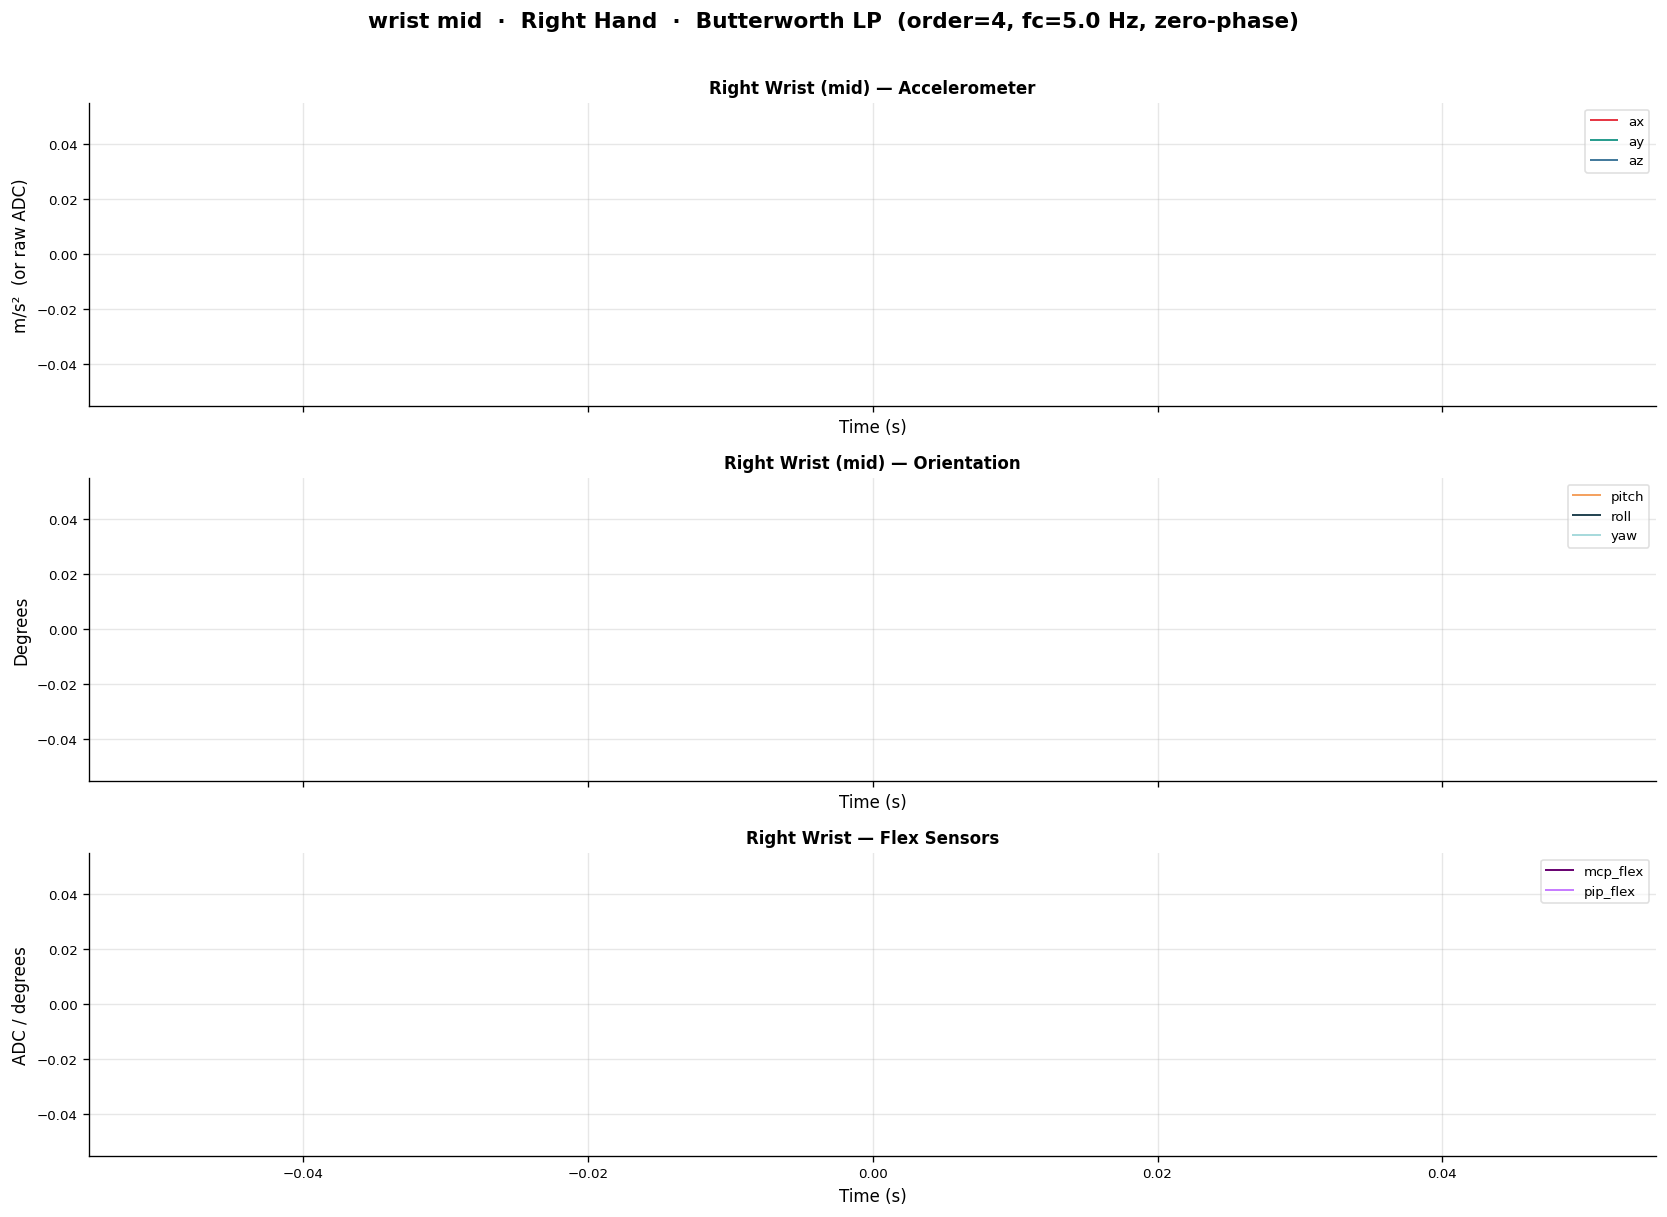

In [54]:
# ── Thumb Mid ──────────────────────────────────────────────────────────────────

finger = "wrist"
segment = "mid"

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    f'{finger} {segment}  ·  {HAND.capitalize()} Hand  ·  {filter_description()}',
    fontsize=13, fontweight='bold', y=1.01
)

plot_segment(df_raw, t, HAND, finger, segment, FS_HZ, FILTER_TYPE, axes)

plt.tight_layout()
plt.show()

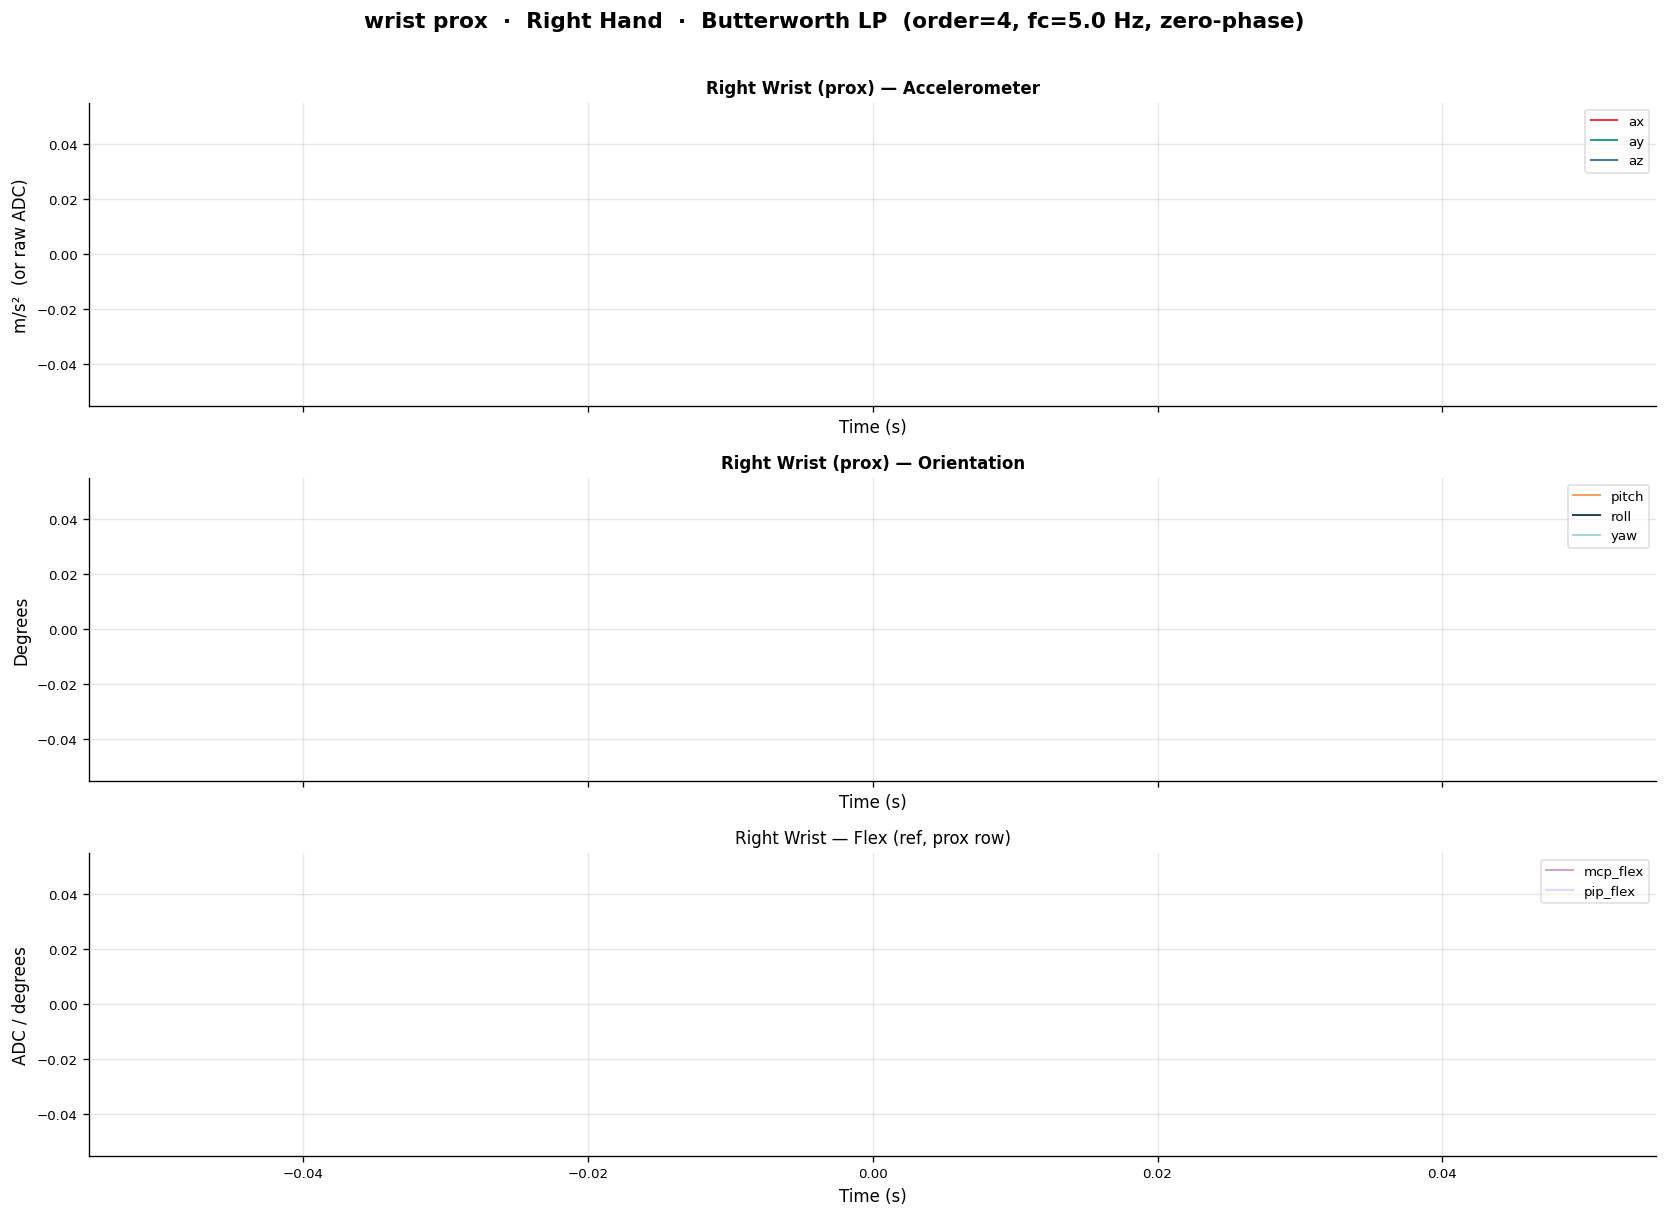

In [55]:
# ── Thumb Prox ─────────────────────────────────────────────────────────────────

segment = "prox"

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    f'{finger} {segment}  ·  {HAND.capitalize()} Hand  ·  {filter_description()}',
    fontsize=13, fontweight='bold', y=1.01
)

plot_segment(df_raw, t, HAND, finger, segment, FS_HZ, FILTER_TYPE, axes)

plt.tight_layout()
plt.show()

---
## 5. Raw vs Filtered Overlay

Direct side-by-side comparison of the raw signal and the filtered output for every channel in both thumb segments.

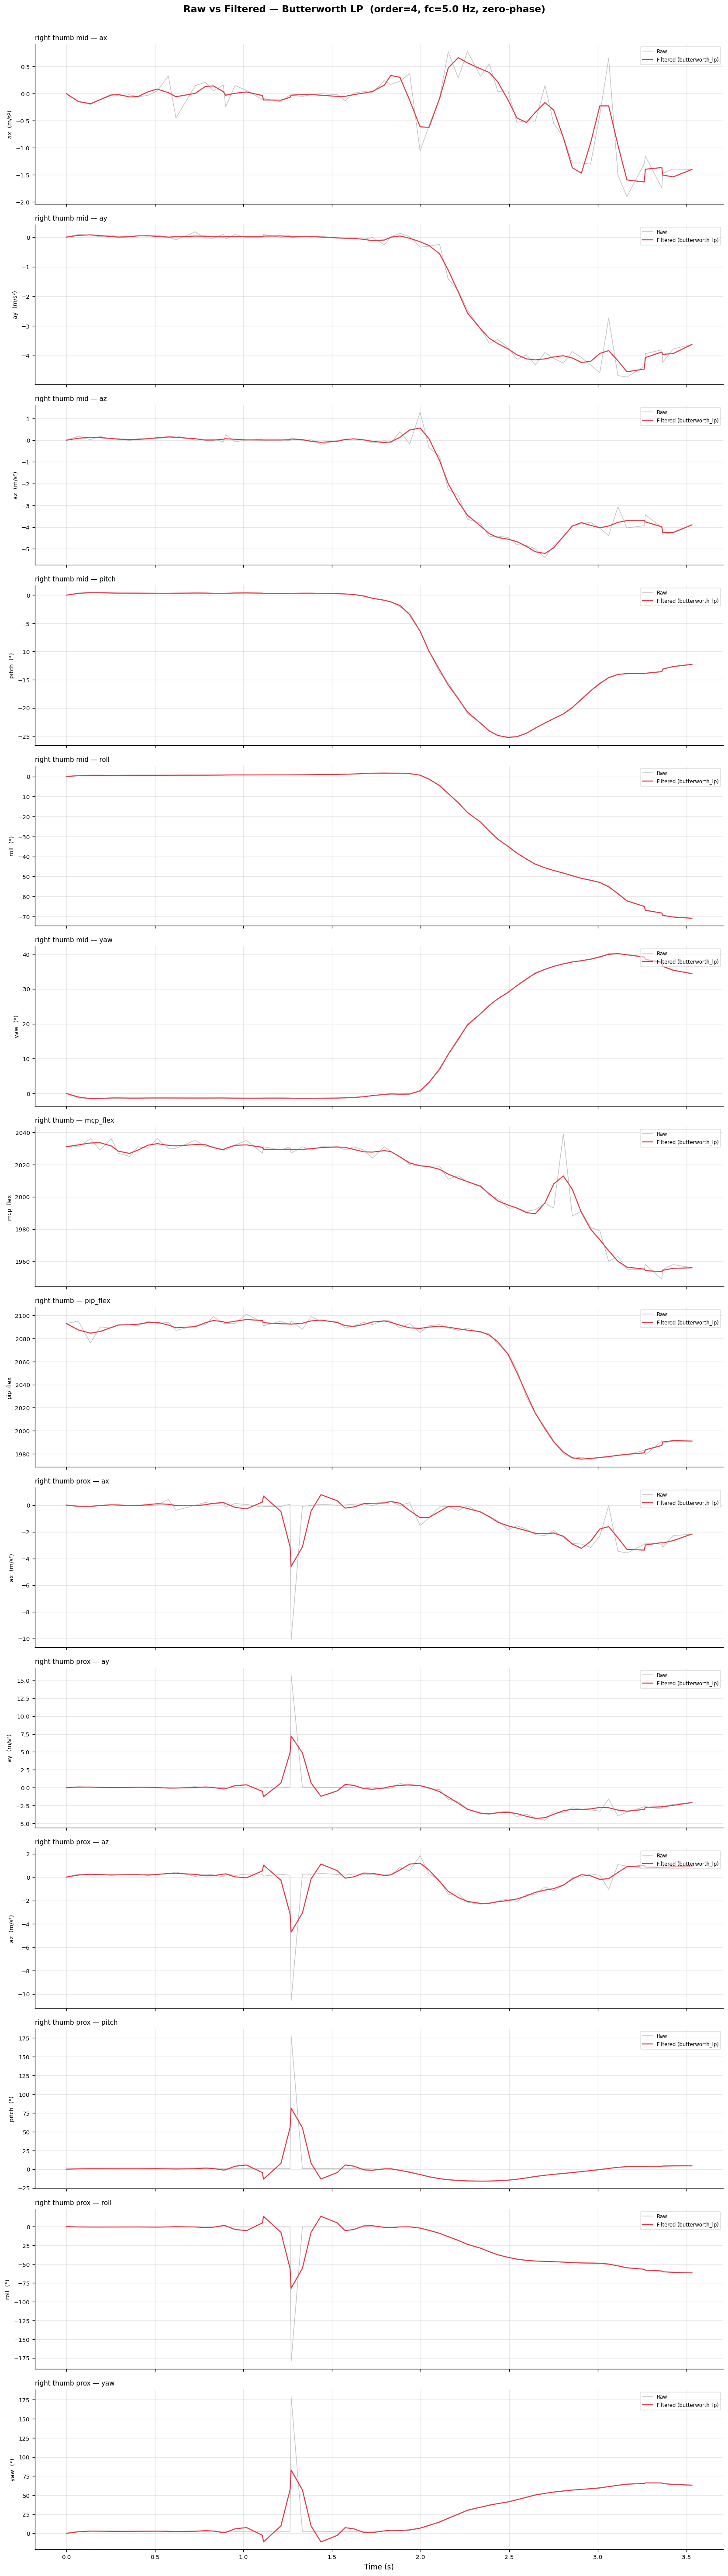

In [56]:
# ── Channels to compare ────────────────────────────────────────────────────────

# Define which segments/locs/channels to include in the overlay.
# Each entry: (segment, loc, channel, y-label)
OVERLAY_CHANNELS = [
    # Thumb Mid
    ('thumb', 'mid', 'ax',       'ax  (m/s²)'),
    ('thumb', 'mid', 'ay',       'ay  (m/s²)'),
    ('thumb', 'mid', 'az',       'az  (m/s²)'),
    ('thumb', 'mid', 'pitch',    'pitch  (°)'),
    ('thumb', 'mid', 'roll',     'roll  (°)'),
    ('thumb', 'mid', 'yaw',      'yaw  (°)'),
    # Flex (segment-level, not loc-specific)
    ('thumb', None,  'mcp_flex', 'mcp_flex'),
    ('thumb', None,  'pip_flex', 'pip_flex'),
    # Thumb Prox
    ('thumb', 'prox', 'ax',      'ax  (m/s²)'),
    ('thumb', 'prox', 'ay',      'ay  (m/s²)'),
    ('thumb', 'prox', 'az',      'az  (m/s²)'),
    ('thumb', 'prox', 'pitch',   'pitch  (°)'),
    ('thumb', 'prox', 'roll',    'roll  (°)'),
    ('thumb', 'prox', 'yaw',     'yaw  (°)'),
]

ncols = 2
nrows = len(OVERLAY_CHANNELS)

fig, axes = plt.subplots(nrows, 1, figsize=(14, 3.5 * nrows), sharex=True)
fig.suptitle(
    f'Raw vs Filtered — {filter_description()}',
    fontsize=13, fontweight='bold', y=1.002
)

for i, (seg, loc, ch, ylabel) in enumerate(OVERLAY_CHANNELS):
    ax = axes[i]
    if loc is not None:
        col_name = f'{HAND}_{seg}_{loc}_{ch}'
        row_label = f'{HAND} {seg} {loc} — {ch}'
    else:
        col_name = f'{HAND}_{seg}_{ch}'
        row_label = f'{HAND} {seg} — {ch}'

    raw  = get_col(df_raw, col_name)
    filt = apply_filter(raw, FILTER_TYPE, FS_HZ)

    ax.plot(t, raw,  color='#AAAAAA', linewidth=0.9, alpha=0.7, label='Raw')
    ax.plot(t, filt, color='#E63946', linewidth=1.4, label=f'Filtered ({FILTER_TYPE})')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(row_label, fontsize=9, loc='left')
    ax.legend(loc='upper right', fontsize=7, framealpha=0.6)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

---
## 6. FFT Spectrum

Frequency content of each channel — before and after filtering.  
Useful for picking cutoff frequencies and diagnosing noise sources.

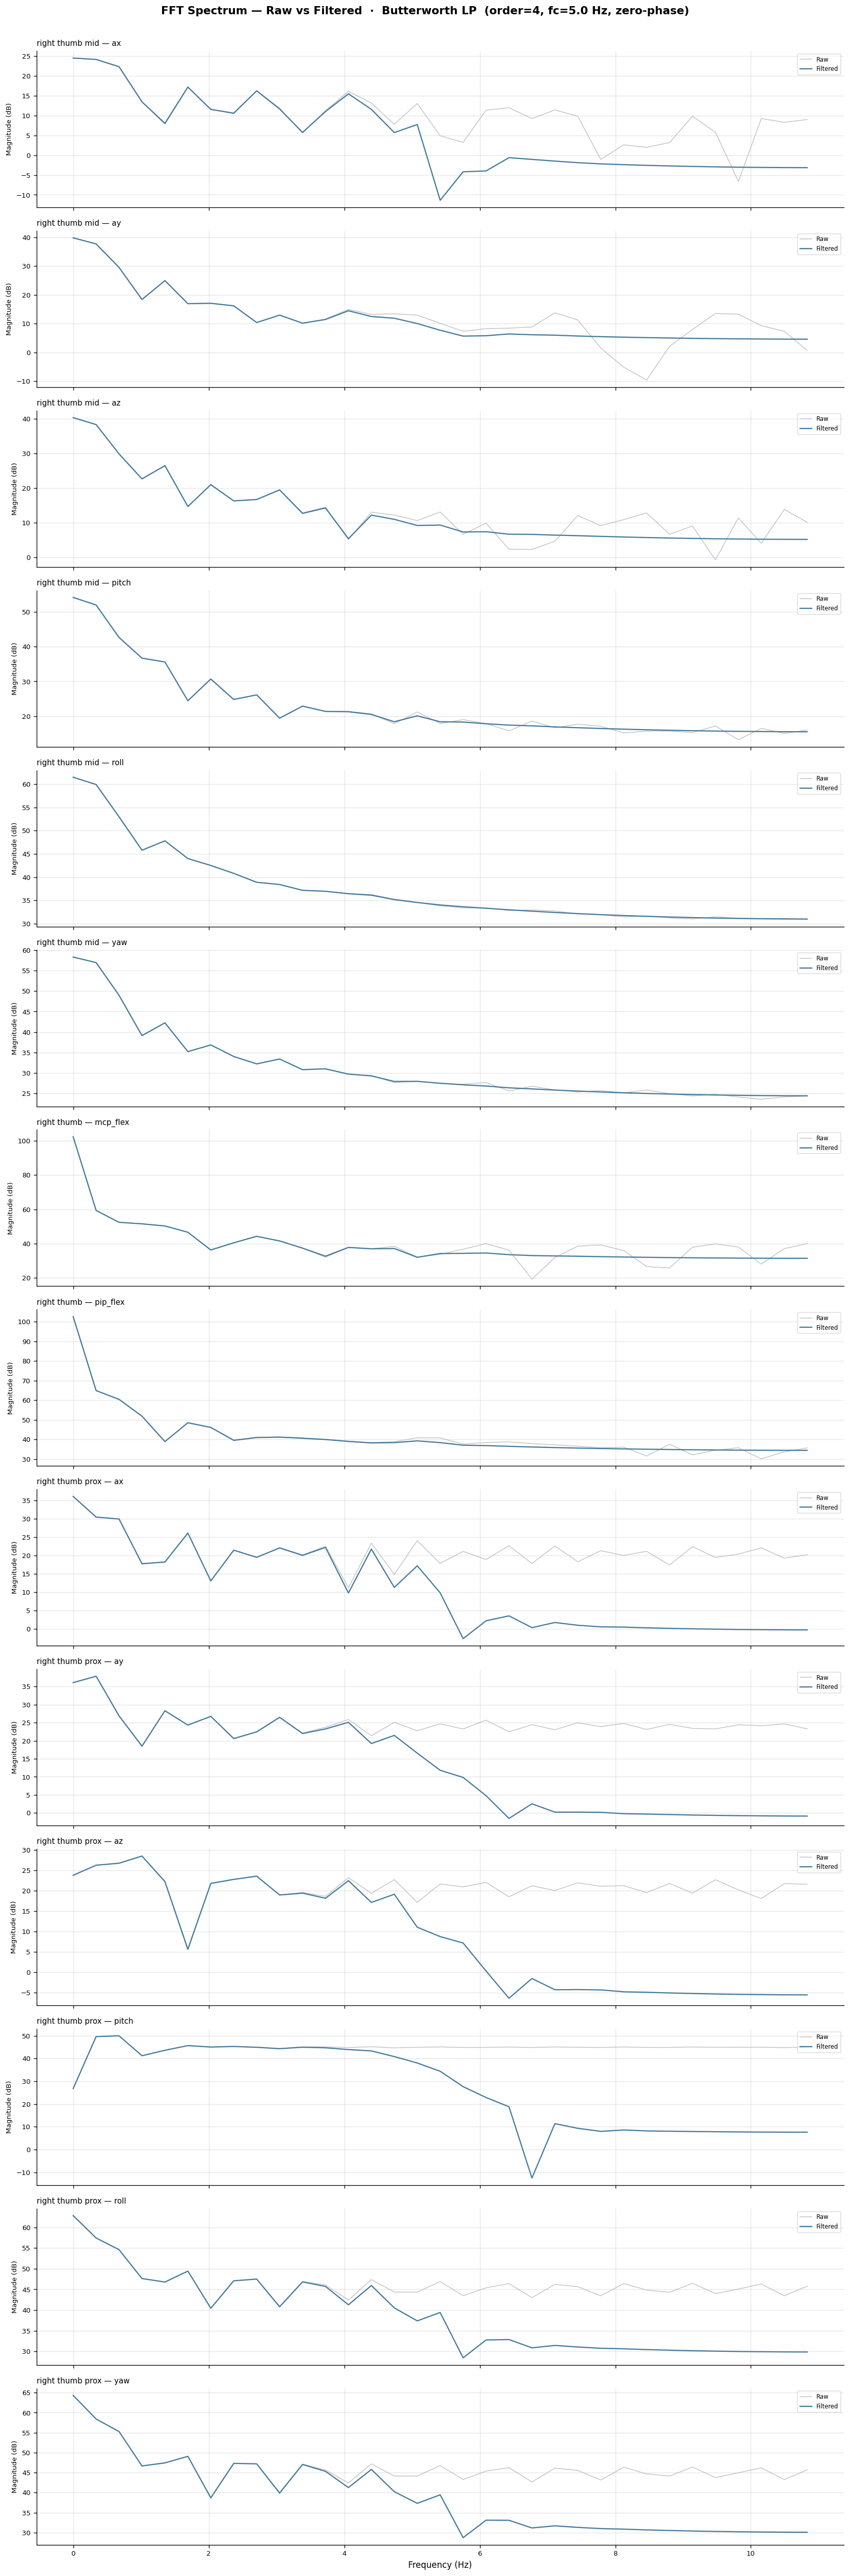

In [57]:
# ── FFT CONFIG ─────────────────────────────────────────────────────────────────
# Which channels to include in the spectrum plots.
# Uses same OVERLAY_CHANNELS list from Section 5.

FFT_DB_SCALE = True          # True = plot in dB (20·log10), False = linear magnitude
FFT_FREQ_MAX = None          # Max frequency to display (Hz). None = Nyquist

# ── Plot ───────────────────────────────────────────────────────────────────────

nrows = len(OVERLAY_CHANNELS)
fig, axes = plt.subplots(nrows, 1, figsize=(14, 3.0 * nrows), sharex=True)
fig.suptitle(
    f'FFT Spectrum — Raw vs Filtered  ·  {filter_description()}',
    fontsize=13, fontweight='bold', y=1.002
)

freq_max = FFT_FREQ_MAX if FFT_FREQ_MAX else FS_HZ / 2.0

for i, (seg, loc, ch, ylabel) in enumerate(OVERLAY_CHANNELS):
    ax = axes[i]
    if loc is not None:
        col_name = f'{HAND}_{seg}_{loc}_{ch}'
        row_label = f'{HAND} {seg} {loc} — {ch}'
    else:
        col_name = f'{HAND}_{seg}_{ch}'
        row_label = f'{HAND} {seg} — {ch}'

    raw  = get_col(df_raw, col_name)
    filt = apply_filter(raw, FILTER_TYPE, FS_HZ)

    # Remove NaNs for FFT
    valid = ~np.isnan(raw)
    if valid.sum() < 4:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes, ha='center')
        ax.set_title(row_label, fontsize=9, loc='left')
        continue

    N    = valid.sum()
    freqs = rfftfreq(N, d=1.0 / FS_HZ)
    mag_raw  = np.abs(rfft(raw[valid]))
    mag_filt = np.abs(rfft(filt[valid]))

    if FFT_DB_SCALE:
        eps = 1e-10
        mag_raw  = 20 * np.log10(mag_raw  + eps)
        mag_filt = 20 * np.log10(mag_filt + eps)
        ylabel_fft = 'Magnitude (dB)'
    else:
        ylabel_fft = 'Magnitude'

    freq_mask = freqs <= freq_max
    ax.plot(freqs[freq_mask], mag_raw[freq_mask],  color='#AAAAAA', linewidth=0.9, alpha=0.7, label='Raw')
    ax.plot(freqs[freq_mask], mag_filt[freq_mask], color='#457B9D', linewidth=1.4, label='Filtered')
    ax.set_ylabel(ylabel_fft, fontsize=8)
    ax.set_title(row_label, fontsize=9, loc='left')
    ax.legend(loc='upper right', fontsize=7, framealpha=0.6)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

---
## 7. Export Filtered Data

Save a filtered version of the loaded CSV with the same column structure.

In [58]:
# ── Export config ──────────────────────────────────────────────────────────────

# Columns to filter and export.
# Set to None to filter ALL numeric columns that match the HAND prefix.
EXPORT_COLS = None

# Output path — leave None to auto-generate next to the source file.
EXPORT_PATH = None

# ── Run export ─────────────────────────────────────────────────────────────────

df_export = df_raw.copy()

if EXPORT_COLS is None:
    # Filter all numeric columns belonging to the selected hand
    cols_to_filter = [
        c for c in df_raw.columns
        if c.startswith(f'{HAND}_') and pd.api.types.is_numeric_dtype(df_raw[c])
    ]
else:
    cols_to_filter = EXPORT_COLS

for col in cols_to_filter:
    df_export[col] = apply_filter(df_raw[col].to_numpy(dtype=float), FILTER_TYPE, FS_HZ)

if EXPORT_PATH is None:
    base, ext = os.path.splitext(csv_path)
    out_path = f"{base}_filtered_{FILTER_TYPE}{ext}"
else:
    out_path = EXPORT_PATH

df_export.to_csv(out_path, index=False)
print(f'Exported filtered CSV ({len(cols_to_filter)} columns filtered):')
print(f'  {out_path}')

Exported filtered CSV (145 columns filtered):
  /home/jestin/ThesisRepo/ML/3D_Reconstruction/glove_data_flat2fist_2s_1_2026-04-26_16-41-36_filtered_butterworth_lp.csv
